# E-Commerce / Superstore Sales Performance Analysis

## 1. Project Introduction

This project analyzes Superstore sales data to understand sales, profitability, 
customer behavior, product performance, regional trends, shipping performance, 
and the relationship between discounts and profit.

**Tools:** Python, NumPy, Pandas, Matplotlib, Seaborn

## 2. Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Understanding the Dataset

In [6]:
df = pd.read_csv("data/superstore.csv", encoding="latin-1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [8]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [9]:
print("\nShape:\n", df.shape)

print("\nColumns:\n", df.columns)

print("\nData types:\n", df.dtypes)

print("\nMissing values:\n", df.isnull().sum())

print("\nDuplicated values:", df.duplicated().sum())


Shape:
 (9994, 21)

Columns:
 Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

Data types:
 Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode      

## 4. Data Cleaning & Preparation

### Converting Date Columns

The `Order Date` and `Ship Date` columns are initially stored as strings (`object`).
We convert them to Pandas datetime format so that we can perform
time-based analysis such as extracting the year and month.

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [11]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date","Ship Date","Shipping Days"]].head()


,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [12]:
df["Shipping Days"].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [13]:
print("Average Shipping Days:", df["Shipping Days"].mean())

Average Shipping Days: 3.958174904942966


In [14]:
df.groupby("Ship Mode")["Shipping Days"].agg(["mean", "count", "std", "min", "max"])

,mean,count,std,min,max
Ship Mode,,,,,
First Class,2.182705,1538,0.773529,1,4
Same Day,0.044199,543,0.205726,0,1
Second Class,3.238046,1945,1.188245,1,5
Standard Class,5.006535,5968,1.010813,3,7


## 5. Categorical Data Exploration

In [15]:
print("Category Frequency:",df["Category"].unique())
print("\nCategory count:\n",df["Category"].value_counts())

print("\nRegion Frequency:\n",df["Region"].unique())
print("\nRegion count:\n",df["Region"].value_counts())

print("\nSegment Frequency:\n",df["Segment"].unique())
print("\nSegment count:\n",df["Segment"].value_counts())

Category Frequency: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

Category count:
 Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Region Frequency:
 <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

Region count:
 Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

Segment Frequency:
 <StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

Segment count:
 Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


## 6. Sales Analysis

In [16]:
df.groupby("Ship Mode")["Order ID"].nunique()

Ship Mode
First Class        787
Same Day           264
Second Class       964
Standard Class    2994
Name: Order ID, dtype: int64

In [17]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

### 6.1 Sales by Category

In [18]:
category_sales= df.groupby("Category")["Sales"].agg( 
    Total_Sales="sum",
    Average_Sales="mean",
    Number_of_Orders="count")

category_sorted = category_sales.sort_values("Total_Sales")
category_sorted

,Total_Sales,Average_Sales,Number_of_Orders
Category,,,
Office Supplies,719047.0320,119.324101,6026
Furniture,741999.7953,349.834887,2121
Technology,836154.0330,452.709276,1847


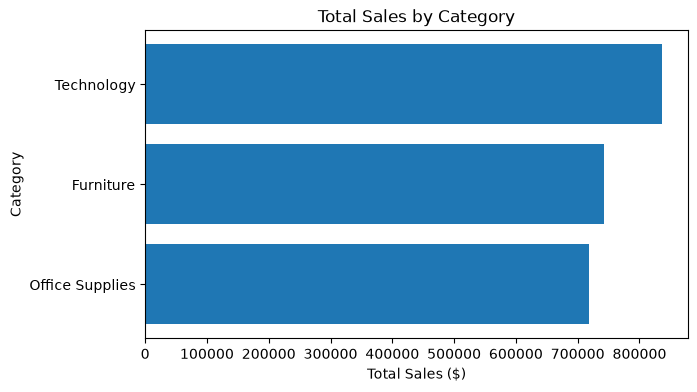

In [19]:
plt.figure(figsize=(7,4))
plt.style.use("default")
plt.barh(category_sorted.index, category_sorted["Total_Sales"])
plt.title("Total Sales by Category")
plt.xlabel("Total Sales ($)")
plt.ylabel("Category")
plt.show()

### 6.2 Sales by Sub-Category

In [20]:
subcat_sales = df.groupby("Sub-Category")["Sales"].agg(
    Total_Sales="sum",
    Average_Sales="mean",
    Number_of_Orders="count"
).sort_values("Total_Sales")

subcat_sales


,Total_Sales,Average_Sales,Number_of_Orders
Sub-Category,,,
Fasteners,3024.2800,13.936774,217
Labels,12486.3120,34.303055,364
Envelopes,16476.4020,64.867724,254
Art,27118.7920,34.068834,796
Supplies,46673.5380,245.650200,190
Paper,78479.2060,57.284092,1370
Furnishings,91705.1640,95.825668,957
Appliances,107532.1610,230.755710,466
Bookcases,114879.9963,503.859633,228


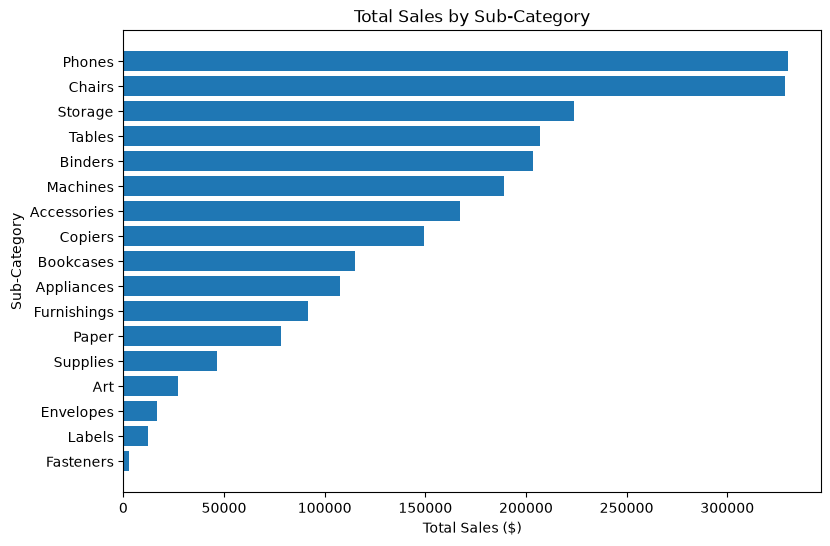

In [21]:
plt.style.use("default")
plt.figure(figsize=(9,6))
           
plt.barh(subcat_sales.index, subcat_sales["Total_Sales"])

plt.xlabel("Total Sales ($)")
plt.ylabel("Sub-Category")
plt.title("Total Sales by Sub-Category")
plt.show()

### 6.3/6.4 Sales by Region and State

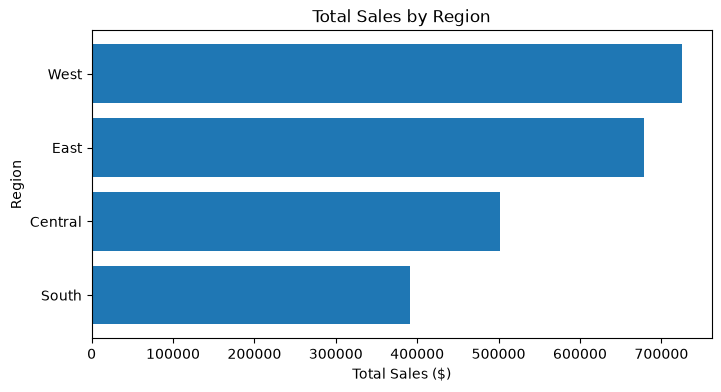

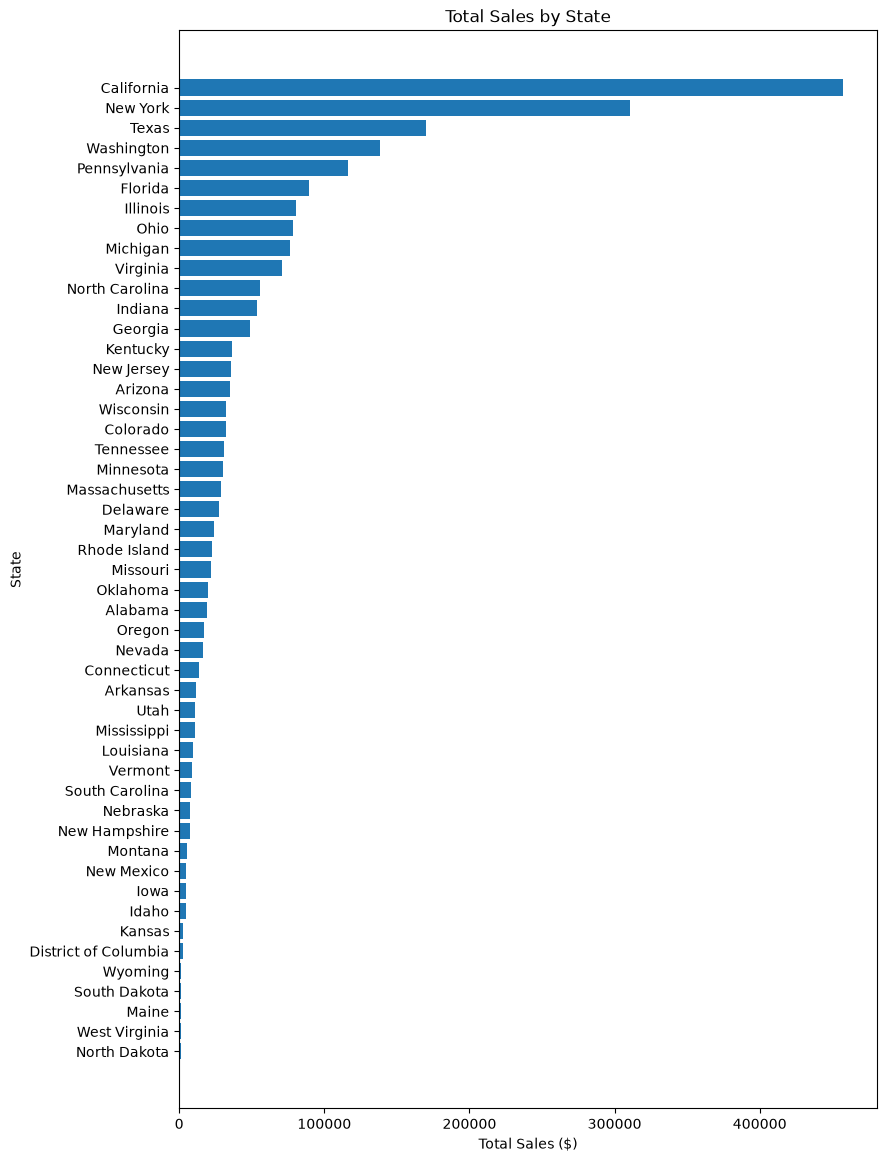

In [22]:
region_sales = df.groupby("Region")["Sales"].agg(
    Total_Sales="sum",
    Average_Sales="mean",
    Number_of_Orders="count"
).sort_values("Total_Sales")

state_sales = df.groupby("State")["Sales"].agg(
    Total_Sales="sum",
    Average_Sales="mean",
    Number_of_Orders="count"
).sort_values("Total_Sales")

# Region — small, fine as one figure
plt.figure(figsize=(8,4))
plt.barh(region_sales.index, region_sales["Total_Sales"])
plt.title("Total Sales by Region")
plt.xlabel("Total Sales ($)")
plt.ylabel("Region")
plt.show()

# State — needs real vertical room for 49 labels
plt.figure(figsize=(9,14))
plt.barh(state_sales.index, state_sales["Total_Sales"])
plt.title("Total Sales by State")
plt.xlabel("Total Sales ($)")
plt.ylabel("State")
plt.show()



## 7. Profit Analysis
### 7.1 Profit by Category

In [23]:
category_profit = df.groupby("Category")["Profit"].agg(
    Total_Profit="sum",
    Average_Profit="mean",
    Number_of_Orders="count"
)
category_profit["Profit_Margin"] = category_profit["Total_Profit"] / category_sales["Total_Sales"]

category_profit

,Total_Profit,Average_Profit,Number_of_Orders,Profit_Margin
Category,,,,
Furniture,18451.2728,8.699327,2121,0.024867
Office Supplies,122490.8008,20.327050,6026,0.170352
Technology,145454.9481,78.752002,1847,0.173957


The profit margin of furniture is 0.025 which is nearly 7x times lower than office supplies and technology (~0.17)
each.

The total profit of furniture is ($ 18451.2) is far smaller than Office Supplies (~$122,491) or Technology (~$145,455) — not because Furniture sells less but specifically because of this margin gap.

## 8. Discount vs. Profit Analysis
### 8.1 Average Discount by Category


In [24]:
df.groupby("Category")["Discount"].mean()

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

Furniture's discount (0.174) vs. Technology's (0.132) vs. Office Supplies (0.157), and  that Office Supplies' discount sits close to Furniture's while its margin doesn't — meaning discount is a contributing factor to Furniture's weak margin, not the whole cause.

### 8.2 Discount vs. Profit Scatter

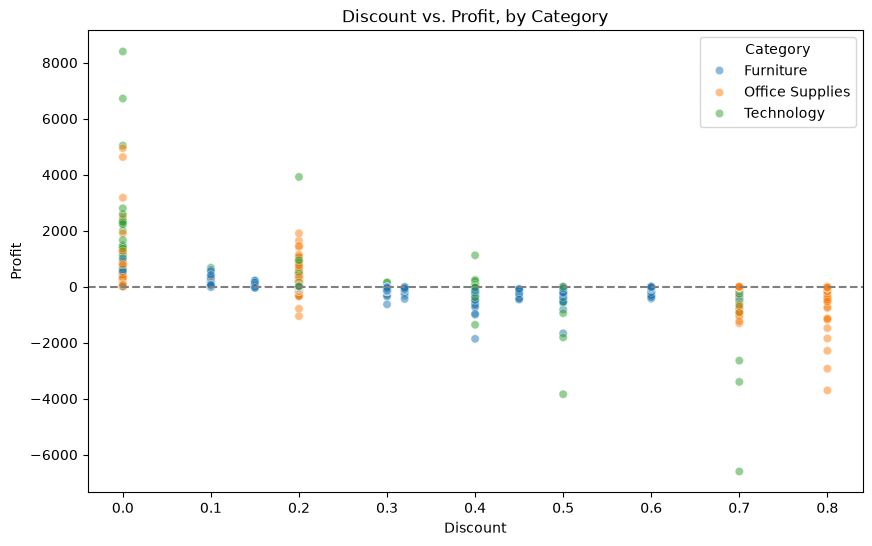

In [25]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category", alpha=0.5)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Discount vs. Profit, by Category")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

Discount-driven losses affect all three categories, but differently. 
Furniture loses money across a broad range of discounts (roughly 30%–60%), with losses that are frequent but individually modest — consistent with its low overall margin (~2.5%). 
Technology stays profitable at moderate discounts more often than Furniture, but its losses, when they occur, are far more severe — one order at 70% discount lost over $6,600, roughly 3.5x Furniture's worst loss. 
Office Supplies falls between the two: losses begin appearing around a 20% discount and grow moderately through 70–80%.

## Key Takeway:-
 This suggests Furniture's weak margin is a systemic discounting problem, while Technology's risk comes from a smaller number of high-severity outlier orders rather than a broad pattern.

## 9. Customer Segment Analysis

In [26]:
segment_summary = df.groupby("Segment").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
)
segment_summary["Profit_Margin"] = segment_summary["Total_Profit"] / segment_summary["Total_Sales"]
segment_summary

,Total_Sales,Total_Profit,Orders,Profit_Margin
Segment,,,,
Consumer,1.161401e+06,134119.2092,2586,0.115481
Corporate,7.061464e+05,91979.1340,1514,0.130255
Home Office,4.296531e+05,60298.6785,909,0.140343


Consumer leads on total sales and profit due to volume, but Home Office and Corporate convert a slightly higher percentage of sales into profit.

## 10. Shipping Analysis

In [27]:
shipping_summary = df.groupby("Ship Mode").agg(
    Avg_Shipping_Days=("Shipping Days", "mean"),
    Orders=("Order ID", "nunique"),
    Total_Sales=("Sales", "sum")
).sort_values("Avg_Shipping_Days")
shipping_summary

,Avg_Shipping_Days,Orders,Total_Sales
Ship Mode,,,
Same Day,0.044199,264,1.283631e+05
First Class,2.182705,787,3.514284e+05
Second Class,3.238046,964,4.591936e+05
Standard Class,5.006535,2994,1.358216e+06


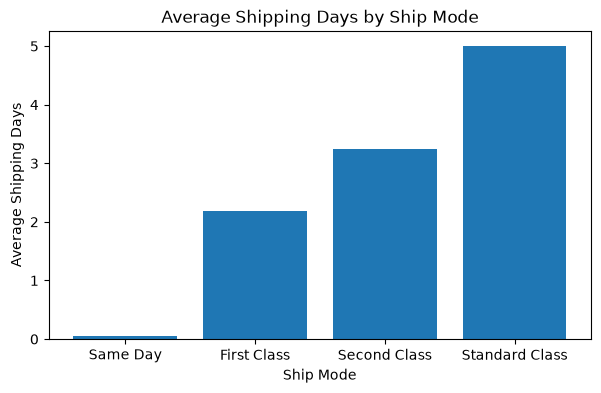

In [28]:
plt.figure(figsize=(7,4))
plt.bar(shipping_summary.index, shipping_summary["Avg_Shipping_Days"])
plt.title("Average Shipping Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")
plt.show()

Same Day shipping is fastest (~0 days) but least used (264 orders); 
Standard Class is the slowest (~5 days) but by far the most popular (2,994 orders) and generates the most total sales (~$1.36M). 
However, average order value is nearly flat across all four modes (~$450–$486), meaning Standard Class's sales lead reflects order volume, not larger individual orders — shipping mode choice doesn't correlate with what customers spend per order.

In [29]:
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month

## 11. Time-Series Analysis

### 11.1 Sales by Year

In [30]:
yearly_sales = df.groupby("Order Year")["Sales"].sum()
yearly_sales

Order Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [31]:
## Checking whether 2017 has a fully yearly sales or partial

df["Order Date"].max()

Timestamp('2017-12-30 00:00:00')

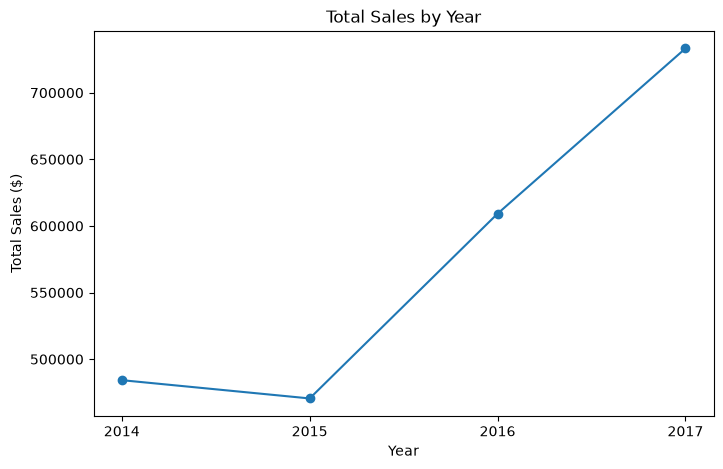

In [32]:
plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker="o")
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.xticks(yearly_sales.index)
plt.ylabel("Total Sales ($)")
plt.show()

The year from 2014-2015 shows a slight dip in the sales but there is a steady-growth in the sales from years 2015-2017 .
Moreover the end year 2017 covered the whole of it sales till december 30

### 11.2 Sales by Month

In [33]:
monthly_sales = df.groupby("Order Month")["Sales"].sum()
monthly_sales

Order Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

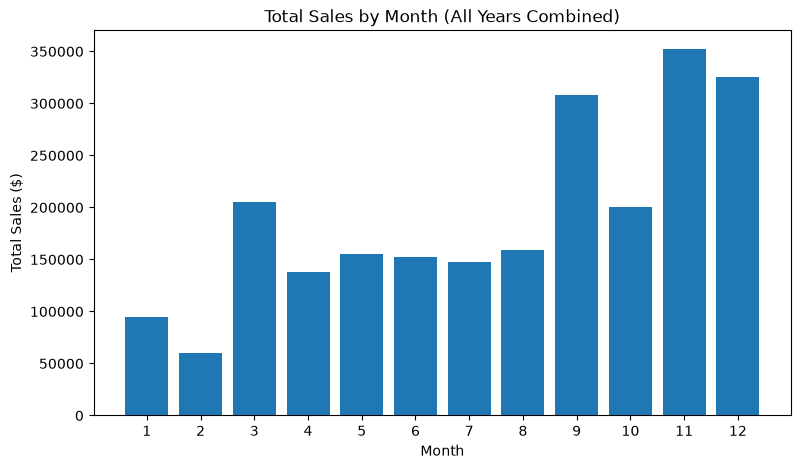

In [34]:
plt.figure(figsize=(9,5))
plt.bar(monthly_sales.index, monthly_sales.values)
plt.title("Total Sales by Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(monthly_sales.index)
plt.show()

The months Jan and Feb show the lowest sales, likely due to a slow start to the calendar year. March has an unexplained spike that doesn't fit the surrounding pattern. Sales are relatively flat through the mid-year months (Apr–Aug), then rise consistently across the last four months (Sept–Dec), peaking in November — likely tied to back-to-school and holiday retail seasonality.

### 11.3 Profit by Year

In [35]:
yearly_profit = df.groupby("Order Year")["Profit"].sum()
yearly_profit

Order Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64

Profit growth outpaced sales growth in 2015 and 2016, but in 2017 profit grew only 14.2% while sales grew 20.4%, meaning that year's growth came with some margin dilution.

### 11.4 Monthly Trend

In [36]:
monthly_trend = df.groupby(["Order Year", "Order Month"])["Sales"].sum()
monthly_trend

Order Year  Order Month
2014        1               14236.8950
            2                4519.8920
            3               55691.0090
            4               28295.3450
            5               23648.2870
            6               34595.1276
            7               33946.3930
            8               27909.4685
            9               81777.3508
            10              31453.3930
            11              78628.7167
            12              69545.6205
2015        1               18174.0756
            2               11951.4110
            3               38726.2520
            4               34195.2085
            5               30131.6865
            6               24797.2920
            7               28765.3250
            8               36898.3322
            9               64595.9180
            10              31404.9235
            11              75972.5635
            12              74919.5212
2016        1               18542.4910
 

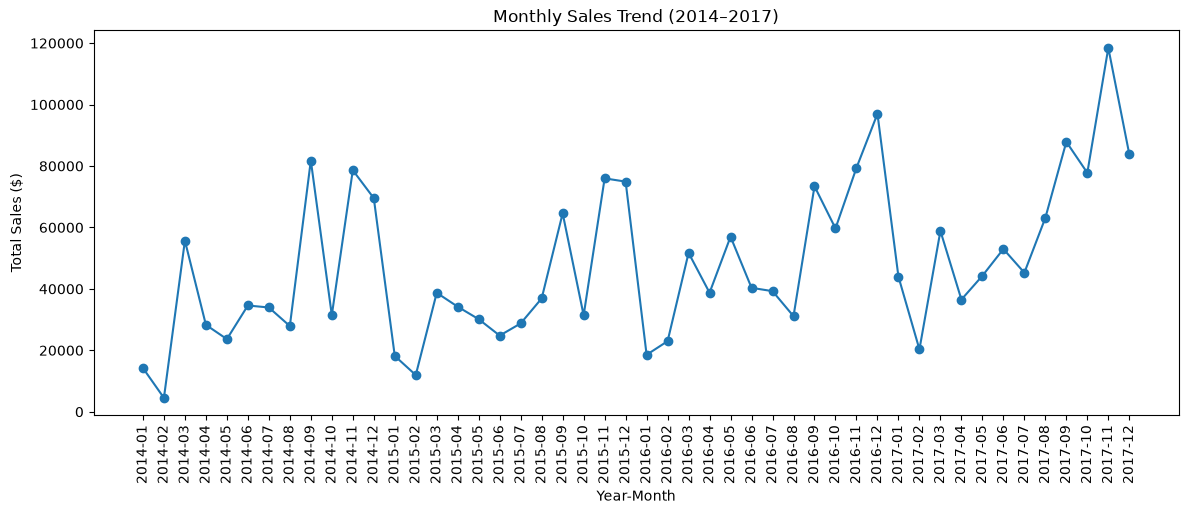

In [37]:
monthly_trend = monthly_trend.reset_index()
monthly_trend["Period"] = monthly_trend["Order Year"].astype(str) + "-" + monthly_trend["Order Month"].astype(str).str.zfill(2)

plt.figure(figsize=(14,5))
plt.plot(monthly_trend["Period"], monthly_trend["Sales"], marker="o")
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend (2014–2017)")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales ($)")
plt.show()

While Q4 (Sep–Dec) tends to be stronger overall, the month-by-month view shows this isn't a clean, repeatable seasonal curve — there's real volatility within Q4 itself (e.g., October often dips between September and the November/December peaks). Part of why November/December looked especially strong in the pooled 11.2 chart is simply that the business grew year over year (per 11.1) — 2017's November peak (~$119K) is roughly 45% higher than 2014's November peak (~$82K), so later years pull the pooled average up. The takeaway: Q4 strength is real, but it's driven by a mix of mild seasonality and overall business growth, not a strong repeatable seasonal effect on its own.

## 12. Product Performance

### 12.1 Top 10 Products by Sales
### 12.2 Top 10 Products by Profit

In [38]:
top_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_profit= df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Products by Sales:\n" ,top_sales)
print("\nTop 10 Products by Profit:\n",top_profit)


Top 10 Products by Sales:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

Top 10 Products by Profit:
 Product Name

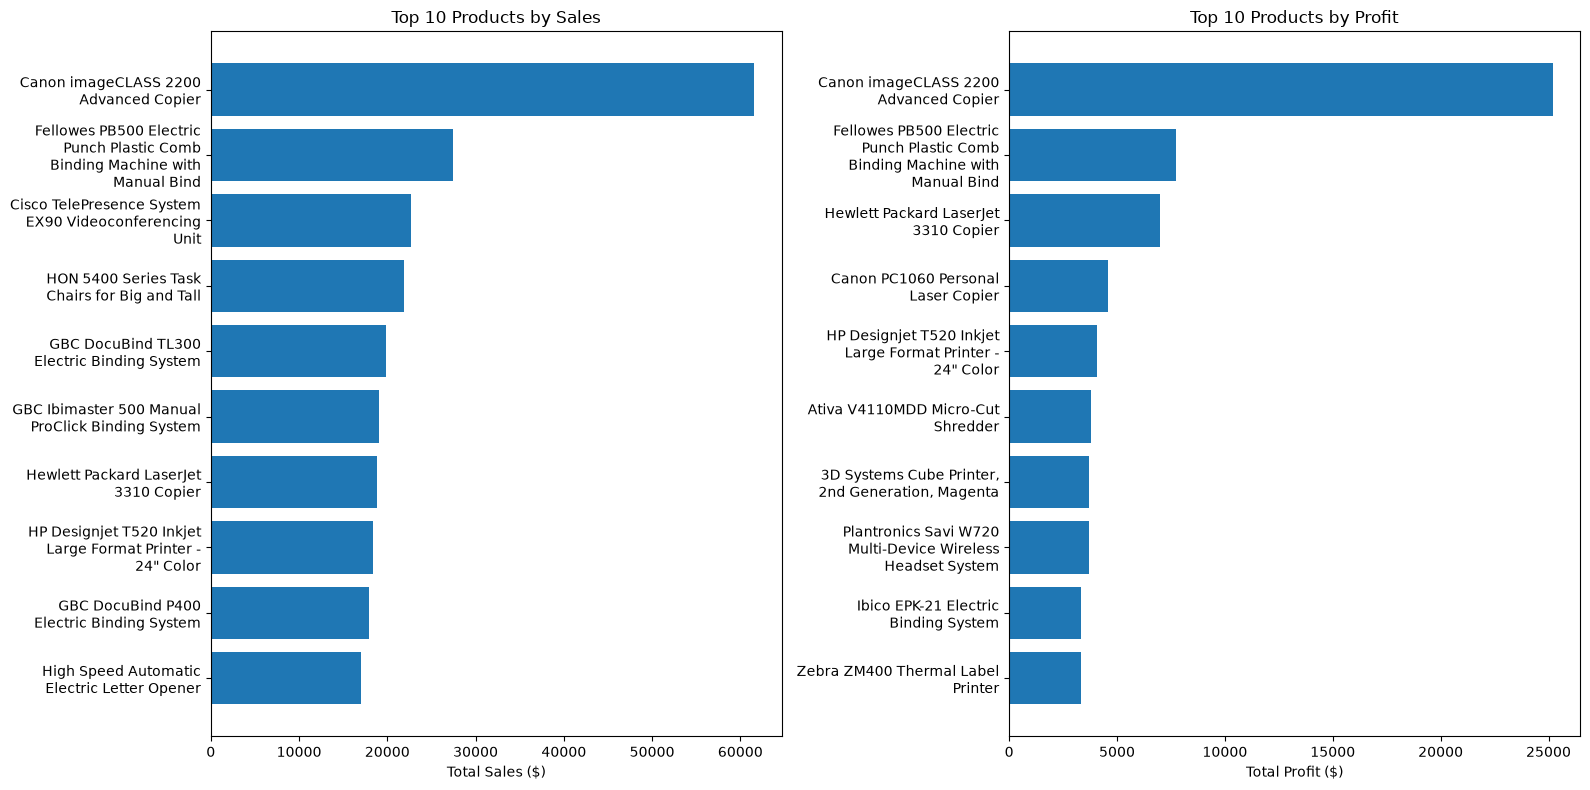

In [39]:
import textwrap

wrapped_sales = [textwrap.fill(l, width=25) for l in top_sales.index]
wrapped_profit = [textwrap.fill(l, width=25) for l in top_profit.index]

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].tick_params(axis='y', labelsize=10)
ax[0].barh(wrapped_sales, top_sales.values)
ax[0].set_title("Top 10 Products by Sales")
ax[0].set_xlabel("Total Sales ($)")
ax[0].invert_yaxis()

ax[1].tick_params(axis='y', labelsize=10)
ax[1].barh(wrapped_profit, top_profit.values)
ax[1].set_title("Top 10 Products by Profit")
ax[1].set_xlabel("Total Profit ($)")
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [40]:
print(df[df["Product Name"] == "Cisco TelePresence System EX90 Videoconferencing Unit"]["Discount"].mean())
print(df[df["Product Name"] == "HON 5400 Series Task Chairs for Big and Tall"]["Discount"].mean())

0.5
0.2


Sales performance doesn't guarantee profit performance at the individual product level. Cisco TelePresence ranks #3 by sales (~$22.6K) but is absent from the profit top 10 — explained by an extreme average discount of 0.5, more than 3x the dataset average (~0.156), which erodes most of its margin. HON Task Chairs shows a similar sales-to-profit disconnect but a smaller discount gap (0.2 vs. 0.156), suggesting a different underlying cause — likely tied to Furniture's inherently thin category-level margins observed in section 7, rather than discounting alone. The same symptom (strong seller, weak profit) can have different root causes across products.

## 13. Quantity Analysis

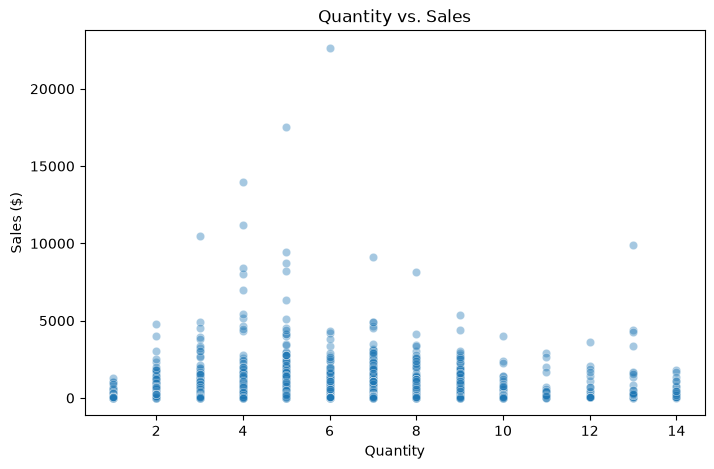

In [41]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Quantity", y="Sales", alpha=0.4)
plt.title("Quantity vs. Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales ($)")
plt.show()



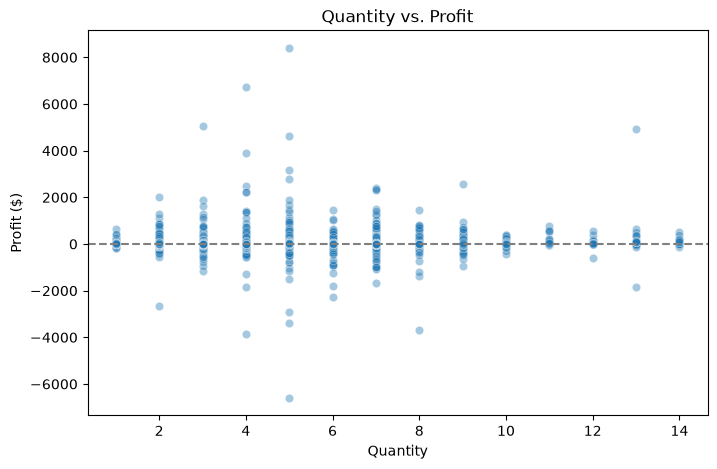

In [42]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Quantity", y="Profit", alpha=0.4)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Quantity vs. Profit")
plt.xlabel("Quantity")
plt.ylabel("Profit ($)")
plt.show()

Quantity shows no meaningful relationship with either Sales or Profit — both scatter plots show similar clusters across the full range of Quantity (1–14), with no visible upward or downward trend. The extreme outliers in both charts (e.g., ~$22,600 in Sales, +$8,400/-$6,600 in Profit) are single high-value transactions rather than evidence of a broader pattern, and they happen to cluster near similar Quantity values by coincidence, not causation. This suggests that what drives Sales and Profit in this dataset is the specific product sold and the discount applied — not how many units are purchased per order.

## 14. Correlation Analysis

In [43]:
corr_cols = df[["Sales", "Quantity", "Discount", "Profit"]].corr()
corr_cols

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


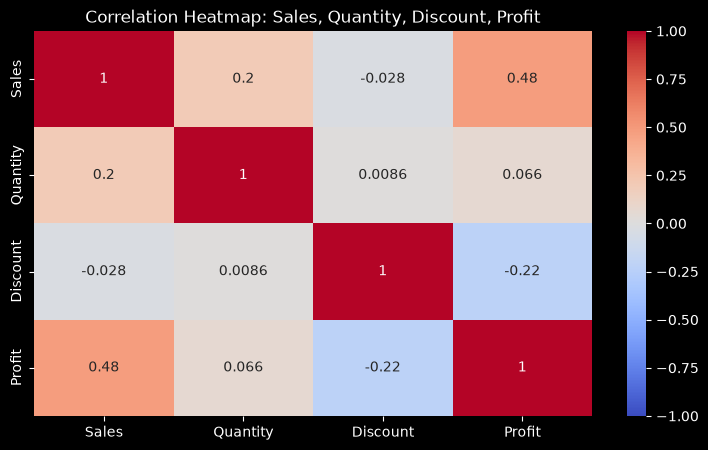

In [45]:
plt.figure(figsize=(9,5))
plt.style.use("dark_background")
sns.heatmap(corr_cols, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Sales, Quantity, Discount, Profit")
plt.show()

(1) Discount↔Profit is negative (-0.22) but only moderate overall, even though specific products/categories showed much sharper effects — because it's an average across ~10,000 orders, most of which aren't extreme cases.

(2)"Quantity has essentially no relationship with Profit (0.066), and only a weak relationship with Sales (0.20) — neither is strong enough to say unit count meaningfully drives value, but Sales shows a slightly more noticeable (if still weak) tendency than Profit does."

(3) Sales↔Profit is the strongest pair (0.48) — a real positive tendency, but not universal, since you've already found real exceptions (Furniture, Cisco TelePresence) where high sales didn't mean high profit.

## 15. Key Visualizations Summary

###  Sales Performance
- Sales by Category (Section 6.1)
- Monthly Sales Trend, 2014–2017 (Section 11.4)

###  Profitability
- Profit by Category and Profit Margin (Section 7.1)
- Discount vs. Profit by Category (Section 8.2)

###  Products
- Top 10 Products by Sales vs. Profit (Section 12.1 / 12.2)

###  Relationships
- Correlation Heatmap: Sales, Quantity, Discount, Profit (Section 14)

## 16. Key Business Insights

1] Technology drives the most revenue on both a total and per-order basis, while Office Supplies' comparable total sales are largely a function of order volume rather than per-order value.

2]The profit margin of furniture is 0.025 which is nearly 7x times lower than office supplies and technology (~0.17)
each.

3] Discount cliff, frequency vs. severity — Furniture's discount-driven losses are frequent but individually modest, spread across a broad 30–60% discount range, while Technology's losses are rare but far more severe — one order at a 70% discount lost over $6,600, roughly 3.5x Furniture's worst loss.

4] Sales dipped slightly in 2015 before growing strongly in 2016 and 2017, though the growth rate itself slightly decelerated (29.5% → 20.4%); profit actually outpaced sales growth in 2015–2016, but fell behind in 2017 (14.2% vs. 20.4%), suggesting some margin dilution that year.

5] A high-selling product doesn't guarantee strong profit — Cisco TelePresence ranks #3 by sales but is absent from the profit top 10 due to an extreme 50% average discount, while HON Task Chairs shows a similar sales-to-profit gap likely tied to Furniture's inherently thin category margin rather than discounting alone.


## 17. Recommendations

1] Furniture margin: Review and likely tighten Furniture's discounting policy, particularly in the 30–60% range where losses are most frequent, and separately investigate whether Furniture's base costs make it structurally thin-margin regardless of discounting.

2] Frequency vs. severity: Apply different controls per category — a broad discount cap for Furniture given its frequent, distributed losses, versus manual review/approval for any Technology order above roughly 50–60% discount, since Technology's risk comes from rare but severe individual orders.

3] Cisco/HON, sales≠profit: Don't rely on category-level discount rules alone — periodically audit individual high-revenue products for hidden margin problems, since a strong seller (like Cisco TelePresence) can still be quietly unprofitable.

4] 2017 margin dilution: Investigate what specifically changed in 2017 — increased discounting, a shift toward lower-margin categories, or something else — before assuming future growth will hold the same profitability.

## 18. Conclusion

This project analyzed Superstore's sales, profit, discount, customer segment, shipping, and time-based data to understand what drives the business's performance. The clearest finding is that Furniture is a structural profitability problem — its margin (~0.025) sits roughly 7x below Office Supplies and Technology (~0.17 each), driven substantially by broad, frequent discounting in the 30–60% range rather than a handful of bad orders. Beyond Furniture, the analysis also showed that strong sales don't guarantee strong profit at the individual product level (Cisco TelePresence, HON Task Chairs) and that 2017's growth came with some margin dilution worth investigating — together suggesting Superstore's next priority should be discount discipline and product-level profit monitoring, not just chasing sales growth.